# NYC Weather and Traffic Delay Prediction

This notebook builds an API-based data pipeline that combines NYC traffic volume data with weather data, stores the cleaned dataset in MySQL, explores congestion patterns, trains weather-aware delay-risk models, and exports Tableau-ready dashboard tables.


## 1. Environment Setup

Install dependencies if needed, then import the libraries used for API ingestion, data cleaning, visualization, modeling, MySQL storage, and Tableau exports.


In [266]:
# Optional: run once if these packages are missing from your notebook kernel.
%pip install openmeteo-requests requests-cache retry-requests


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [267]:
# Optional: run once if these packages are missing from your notebook kernel.
%pip install sqlalchemy pymysql python-dotenv


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Weather API Ingestion

Pull historical weather observations from the Open-Meteo API for New York City. These records become the weather side of the traffic-delay analysis.


In [268]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 40.73061,
	"longitude": -73.935242,
	"start_date": "2020-01-01",
	"end_date": "2025-12-31",
	"daily": [
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",   
    "sunrise",
    "sunset"
],
	"hourly": ["temperature_2m", "relative_humidity_2m", "dew_point_2m", "apparent_temperature", "precipitation", "rain", "snowfall", "snow_depth", "wind_speed_10m"],
	"timezone": "auto",
	"temperature_unit": "fahrenheit",
	"wind_speed_unit": "mph",
	"precipitation_unit": "inch",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_dew_point_2m = hourly.Variables(2).ValuesAsNumpy()
hourly_apparent_temperature = hourly.Variables(3).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(4).ValuesAsNumpy()
hourly_rain = hourly.Variables(5).ValuesAsNumpy()
hourly_snowfall = hourly.Variables(6).ValuesAsNumpy()
hourly_snow_depth = hourly.Variables(7).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(8).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["dew_point_2m"] = hourly_dew_point_2m
hourly_data["apparent_temperature"] = hourly_apparent_temperature
hourly_data["precipitation"] = hourly_precipitation
hourly_data["rain"] = hourly_rain
hourly_data["snowfall"] = hourly_snowfall
hourly_data["snow_depth"] = hourly_snow_depth
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m

hourly_dataframe = pd.DataFrame(data = hourly_data)

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()

daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
daily_temperature_2m_max = daily.Variables(1).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(2).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(3).ValuesAsNumpy()   # ✅ ADD THIS
daily_sunrise = daily.Variables(4).ValuesInt64AsNumpy()
daily_sunset = daily.Variables(5).ValuesInt64AsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["precipitation"] = daily_precipitation_sum
daily_data["sunrise"] = daily_sunrise
daily_data["sunset"] = daily_sunset
daily_dataframe = pd.DataFrame(data = daily_data)

hourly_dataframe.head()

Coordinates: 40.738136291503906°N -73.91488647460938°E
Elevation: 14.0 m asl
Timezone: b'America/New_York'b'GMT-4'
Timezone difference to GMT+0: -14400s


,date,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,wind_speed_10m
0,2020-01-01 00:00:00+00:00,39.829998,79.699532,34.070000,32.075100,0.0,0.0,0.0,0.0,10.088845
1,2020-01-01 01:00:00+00:00,38.209999,75.076363,31.010000,29.407892,0.0,0.0,0.0,0.0,11.428421
2,2020-01-01 02:00:00+00:00,35.779999,77.071312,29.299999,26.927099,0.0,0.0,0.0,0.0,10.963583
3,2020-01-01 03:00:00+00:00,34.790001,78.990501,28.940001,26.067801,0.0,0.0,0.0,0.0,10.535296
4,2020-01-01 04:00:00+00:00,34.160000,77.779877,27.950001,24.650108,0.0,0.0,0.0,0.0,12.081872


## 3. Traffic API Ingestion

Pull NYC traffic volume records directly from the NYC Open Data API. The project uses API ingestion instead of CSV files.


In [269]:
import requests
import pandas as pd

url = "https://data.cityofnewyork.us/resource/7ym2-wayt.json?$limit=50000"

response = requests.get(url)
data = response.json()

df_traffic = pd.DataFrame(data)

print(df_traffic.head())
print(df_traffic.columns)

  requestid    boro    yr  m  d hh  mm vol segmentid  \
0     12512  Queens  2013  3  7  4  15   5     55135   
1     12512  Queens  2013  3  7  4  30   8     55135   
2     12512  Queens  2013  3  7  4  45   8     55135   
3     12512  Queens  2013  3  7  5   0   7     55135   
4     12512  Queens  2013  3  7  5  15   9     55135   

                      wktgeom  street     fromst           tost direction  
0  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
1  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
2  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
3  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
4  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
Index(['requestid', 'boro', 'yr', 'm', 'd', 'hh', 'mm', 'vol', 'segmentid',
       'wktgeom', 'street', 'fromst', 'tost', 'direction'],
      dtype='str')


## 4. Clean, Align, and Merge

Standardize date and hour fields, merge traffic and weather records, and create the final modeling table.


In [270]:
hourly_dataframe["date"] = pd.to_datetime(hourly_dataframe["date"])
hourly_dataframe["date"] = hourly_dataframe["date"].dt.tz_localize(None)

hourly_dataframe["date_only"] = hourly_dataframe["date"].dt.date
hourly_dataframe["hour"] = hourly_dataframe["date"].dt.hour

In [271]:
df_traffic["date"] = pd.to_datetime(
    df_traffic["yr"].astype(str) + "-" +
    df_traffic["m"].astype(str) + "-" +
    df_traffic["d"].astype(str)
)

df_traffic["hour"] = df_traffic["hh"].astype(int)
df_traffic["vol"] = pd.to_numeric(df_traffic["vol"], errors="coerce")

df_traffic = df_traffic.dropna(subset=["date", "hour", "vol"])

In [272]:
df_traffic["date"] = pd.to_datetime(df_traffic["date"])
hourly_dataframe["date_only"] = pd.to_datetime(hourly_dataframe["date"].dt.date)

In [273]:
df_merged = pd.merge(
    df_traffic,
    hourly_dataframe,
    left_on=["date", "hour"],
    right_on=["date_only", "hour"],
    how="inner"
)

In [274]:
df_merged = df_merged.rename(columns={"date_x": "date"})

In [275]:
df_final = df_merged[[
    "date",
    "hour",
    "boro",
    "street",
    "fromst",
    "tost",
    "direction",
    "vol",
    "temperature_2m",
    "precipitation"
]].copy()

df_final = df_final.dropna()

In [276]:
# Preview the merged dataset before writing to MySQL.
display(df_final.head())
print(f"Final rows: {len(df_final):,}")


,date,hour,boro,street,fromst,tost,direction,vol,temperature_2m,precipitation
0,2023-11-15,20,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,20,45.139999,0.0
1,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,15,45.950001,0.0
2,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,26,45.950001,0.0
3,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,23,45.950001,0.0
4,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,13,45.950001,0.0


Final rows: 8,776


## 5. MySQL Storage

Create/connect to the MySQL database and write the API-generated final table. This keeps Tableau and downstream analysis connected to database tables rather than local CSV files.


In [277]:
import os
from urllib.parse import quote_plus
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv()

MYSQL_USER = os.getenv("MYSQL_USER", "root")
MYSQL_PASSWORD = quote_plus(os.getenv("MYSQL_PASSWORD", "your_password"))
MYSQL_HOST = os.getenv("MYSQL_HOST", "localhost")
MYSQL_PORT = os.getenv("MYSQL_PORT", "3306")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE", "weather_traffic")

# Connect to MySQL server, not a specific database yet
server_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/",
    pool_pre_ping=True
)

with server_engine.connect() as conn:
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {MYSQL_DATABASE}"))
    conn.commit()

# Now connect to the database you created
engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}",
    pool_pre_ping=True
)



In [278]:
df_final.to_sql(
    "weather_traffic_full",
    con=engine,
    if_exists="replace",
    index=False
)

8776

## 6. Exploratory Data Analysis

Explore data quality, traffic patterns, borough differences, weather relationships, and temporal trends before modeling.


In [279]:
import matplotlib.pyplot as plt

eda_df = df_final.copy()
eda_df["date"] = pd.to_datetime(eda_df["date"])
eda_df["vol"] = pd.to_numeric(eda_df["vol"], errors="coerce")
eda_df["temperature_2m"] = pd.to_numeric(eda_df["temperature_2m"], errors="coerce")
eda_df["precipitation"] = pd.to_numeric(eda_df["precipitation"], errors="coerce")
eda_df["day_of_week"] = eda_df["date"].dt.day_name()
eda_df["month"] = eda_df["date"].dt.to_period("M").astype(str)
eda_df["is_raining"] = eda_df["precipitation"] > 0

print(f"Rows: {eda_df.shape[0]:,}")
print(f"Columns: {eda_df.shape[1]:,}")
print(f"Date range: {eda_df['date'].min().date()} to {eda_df['date'].max().date()}")
display(eda_df.head())

Rows: 8,776
Columns: 13
Date range: 2020-01-26 to 2024-06-07


,date,hour,boro,street,fromst,tost,direction,vol,temperature_2m,precipitation,day_of_week,month,is_raining
0,2023-11-15,20,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,20,45.139999,0.0,Wednesday,2023-11,False
1,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,15,45.950001,0.0,Wednesday,2023-11,False
2,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,26,45.950001,0.0,Wednesday,2023-11,False
3,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,23,45.950001,0.0,Wednesday,2023-11,False
4,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,13,45.950001,0.0,Wednesday,2023-11,False


In [280]:
overview = pd.DataFrame({
    "dtype": eda_df.dtypes.astype(str),
    "missing_count": eda_df.isna().sum(),
    "missing_pct": (eda_df.isna().mean() * 100).round(2),
    "unique_values": eda_df.nunique()
})

display(overview)
print(f"Duplicate rows: {eda_df.duplicated().sum():,}")
display(eda_df[["vol", "temperature_2m", "precipitation", "hour"]].describe().T)

,dtype,missing_count,missing_pct,unique_values
date,datetime64[us],0,0.0,161
hour,int64,0,0.0,24
boro,str,0,0.0,5
street,str,0,0.0,70
fromst,str,0,0.0,65
tost,str,0,0.0,61
direction,str,0,0.0,4
vol,int64,0,0.0,677
temperature_2m,float32,0,0.0,662
precipitation,float32,0,0.0,45


Duplicate rows: 656


,count,mean,std,min,25%,50%,75%,max
vol,8776.0,112.942457,161.516707,0.000000,17.000000,61.000000,142.000000,1295.000000
temperature_2m,8776.0,55.568874,15.686083,14.450001,44.059998,55.580002,67.910004,90.500000
precipitation,8776.0,0.005353,0.028202,0.000000,0.000000,0.000000,0.000000,0.661417
hour,8776.0,11.311418,6.895309,0.000000,5.000000,11.000000,17.000000,23.000000


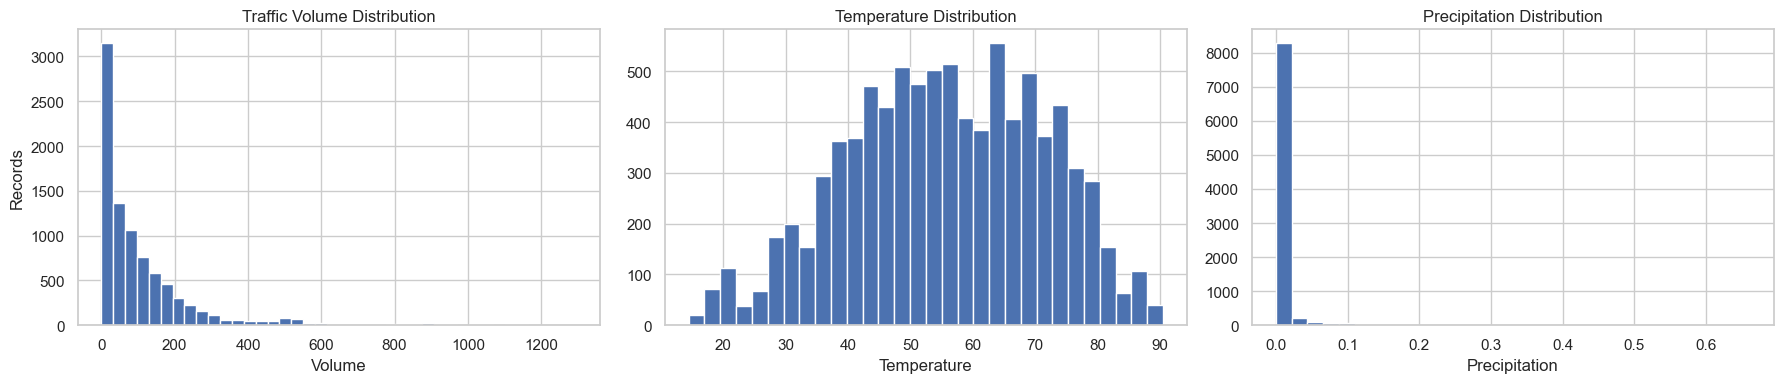

In [281]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

eda_df["vol"].hist(bins=40, ax=axes[0])
axes[0].set_title("Traffic Volume Distribution")
axes[0].set_xlabel("Volume")
axes[0].set_ylabel("Records")

eda_df["temperature_2m"].hist(bins=30, ax=axes[1])
axes[1].set_title("Temperature Distribution")
axes[1].set_xlabel("Temperature")

eda_df["precipitation"].hist(bins=30, ax=axes[2])
axes[2].set_title("Precipitation Distribution")
axes[2].set_xlabel("Precipitation")

plt.tight_layout()
plt.show()

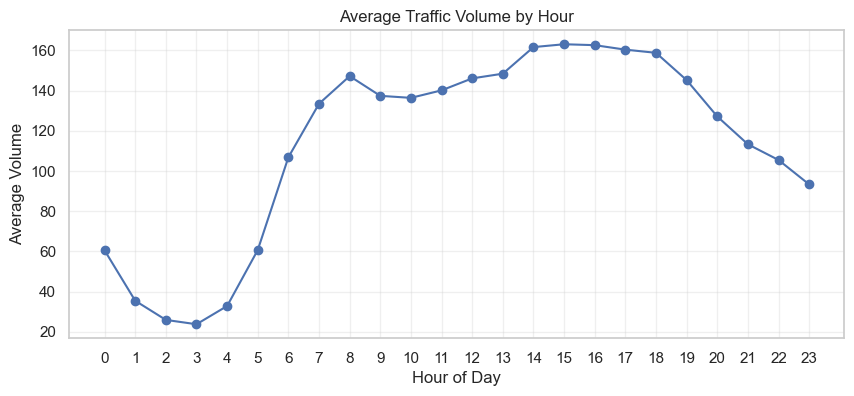

,hour,vol
15,15,163.081232
16,16,162.629526
14,14,161.665738
17,17,160.399433
18,18,158.818713
13,13,148.441489
8,8,147.229111
12,12,146.107612
19,19,145.252226
11,11,140.148936


In [282]:
hourly_pattern = eda_df.groupby("hour", as_index=False)["vol"].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_pattern["hour"], hourly_pattern["vol"], marker="o")
plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Volume")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

display(hourly_pattern.sort_values("vol", ascending=False).head(10))

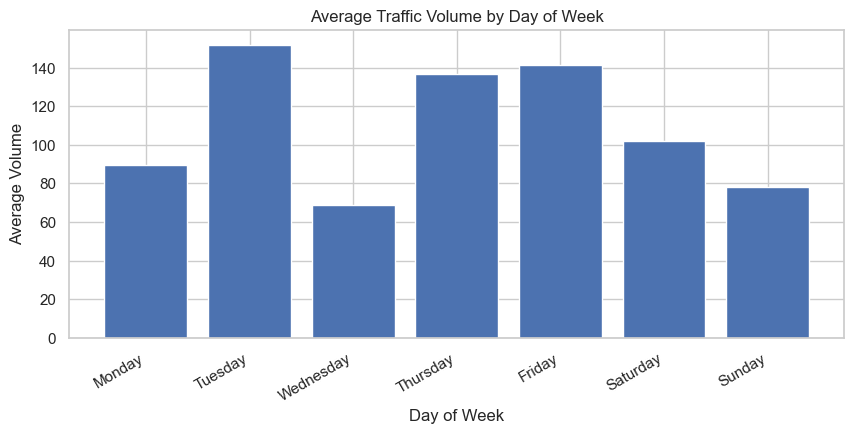

,day_of_week,vol
0,Monday,89.317797
1,Tuesday,151.917834
2,Wednesday,68.658200
3,Thursday,136.588881
4,Friday,141.247605
5,Saturday,102.047809
6,Sunday,78.065217


In [283]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_pattern = eda_df.groupby("day_of_week")["vol"].mean().reindex(day_order).reset_index()

plt.figure(figsize=(10, 4))
plt.bar(day_pattern["day_of_week"], day_pattern["vol"])
plt.title("Average Traffic Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Volume")
plt.xticks(rotation=30, ha="right")
plt.show()

display(day_pattern)

,records,avg_volume,median_volume,max_volume
boro,,,,
Brooklyn,2780,150.629496,79.0,1295
Manhattan,1306,135.843798,127.0,569
Staten Island,315,130.711111,133.0,362
Queens,2586,94.013921,34.0,795
Bronx,1789,61.893236,37.0,263


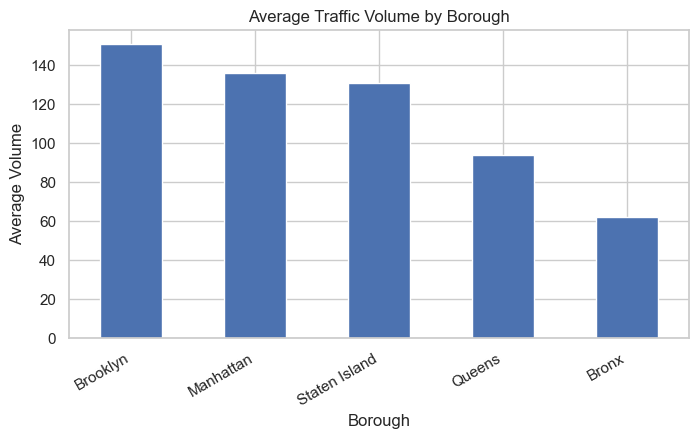

In [284]:
boro_summary = (
    eda_df.groupby("boro")
    .agg(records=("vol", "size"), avg_volume=("vol", "mean"), median_volume=("vol", "median"), max_volume=("vol", "max"))
    .sort_values("avg_volume", ascending=False)
)

display(boro_summary)
boro_summary["avg_volume"].plot(kind="bar", figsize=(8, 4), title="Average Traffic Volume by Borough")
plt.xlabel("Borough")
plt.ylabel("Average Volume")
plt.xticks(rotation=30, ha="right")
plt.show()

In [285]:
street_summary = (
    eda_df.groupby(["boro", "street"])
    .agg(records=("vol", "size"), avg_volume=("vol", "mean"), max_volume=("vol", "max"))
    .query("records >= 5")
    .sort_values("avg_volume", ascending=False)
    .head(15)
)

display(street_summary)

records  avg_volume  max_volume
boro      street                                                           
Brooklyn  BELT PARKWAY                          105  841.133333        1295
          BROOKLYN QUEENS EXPRESSWAY            105  752.076190        1066
Queens    HOOK CREEK BRIDGE                     374  378.390374         682
Manhattan EAST 58 STREET                         23  377.478261         569
Brooklyn  HAMILTON AVENUE                       105  272.180952         740
          GOWANUS EP WB EN HUGH CAREY TNNL      105  270.209524         598
Manhattan AVENUE OF THE AMERICAS                105  263.800000         418
Queens    NORTH CONDUIT AVENUE                   46  252.826087         795
Brooklyn  HAMILTON AVENUE BRIDGE                 71  234.521127         590
          CROPSEY AVENUE                         77  216.740260         371
Queens    BROOKLYN QUEENS EXPRESSWAY             20  215.750000         463
Manhattan 5 AVENUE                              105  214.057143         332
          7 AVENUE                              105  207.676190         309
Bronx     EAST TREMONT AVENUE                    69  183.304348         243
Brooklyn  ATLANTIC AVENUE                       105  178.780952         326

,records,avg_volume,median_volume,avg_temperature,avg_precipitation
is_raining,,,,,
False,7646,113.653675,60.0,55.736092,0.000000
True,1130,108.130088,73.0,54.437401,0.041572


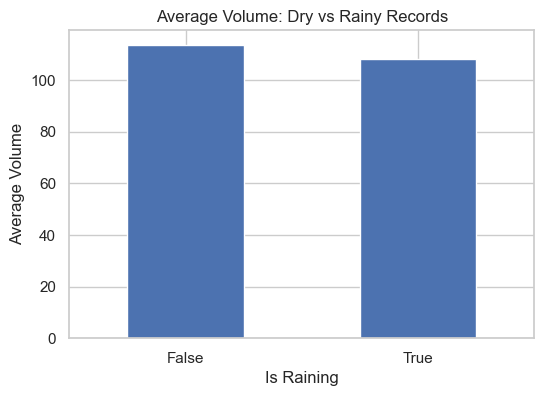

In [286]:
weather_summary = eda_df.groupby("is_raining").agg(
    records=("vol", "size"),
    avg_volume=("vol", "mean"),
    median_volume=("vol", "median"),
    avg_temperature=("temperature_2m", "mean"),
    avg_precipitation=("precipitation", "mean")
)

display(weather_summary)
weather_summary["avg_volume"].plot(kind="bar", figsize=(6, 4), title="Average Volume: Dry vs Rainy Records")
plt.xlabel("Is Raining")
plt.ylabel("Average Volume")
plt.xticks(rotation=0)
plt.show()

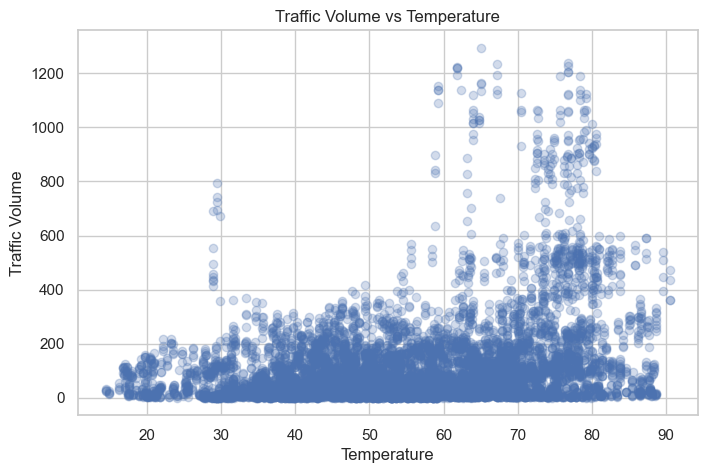

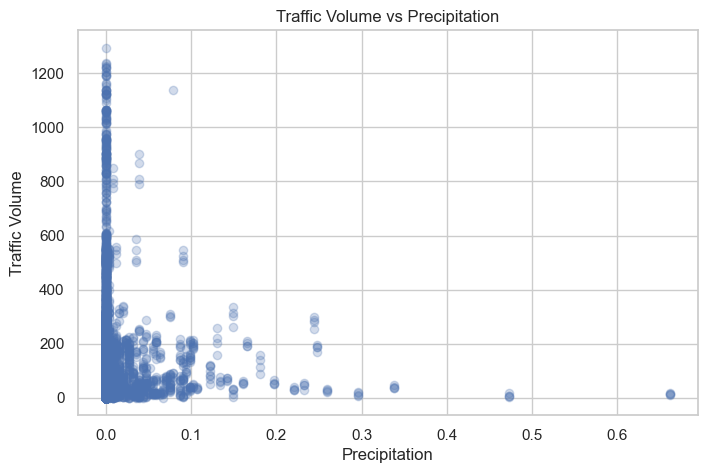

,vol,temperature_2m,precipitation,hour
vol,1.000000,0.303326,-0.022166,0.183205
temperature_2m,0.303326,1.000000,-0.004705,0.194206
precipitation,-0.022166,-0.004705,1.000000,0.000879
hour,0.183205,0.194206,0.000879,1.000000


In [287]:
plt.figure(figsize=(8, 5))
plt.scatter(eda_df["temperature_2m"], eda_df["vol"], alpha=0.25)
plt.title("Traffic Volume vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Traffic Volume")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(eda_df["precipitation"], eda_df["vol"], alpha=0.25)
plt.title("Traffic Volume vs Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Traffic Volume")
plt.show()

display(eda_df[["vol", "temperature_2m", "precipitation", "hour"]].corr())

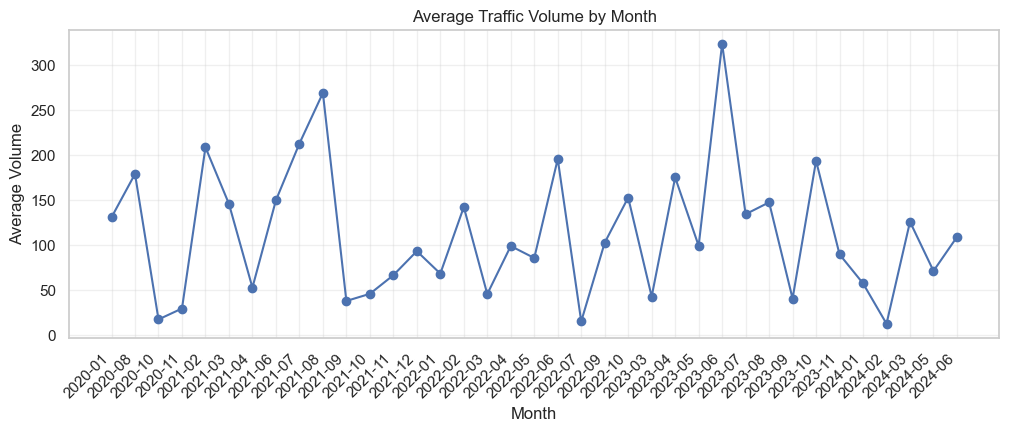

,month,vol
25,2023-05,99.156522
26,2023-06,323.051322
27,2023-07,134.166667
28,2023-08,147.313131
29,2023-09,40.676190
30,2023-10,193.382812
31,2023-11,89.619048
32,2024-01,57.485714
33,2024-02,12.756757
34,2024-03,125.752381


In [288]:
monthly_pattern = eda_df.groupby("month", as_index=False)["vol"].mean()

plt.figure(figsize=(12, 4))
plt.plot(monthly_pattern["month"], monthly_pattern["vol"], marker="o")
plt.title("Average Traffic Volume by Month")
plt.xlabel("Month")
plt.ylabel("Average Volume")
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3)
plt.show()

display(monthly_pattern.tail(12))

In [289]:
if "engine" in globals():
    sql_check = pd.read_sql("""
        SELECT
            boro,
            COUNT(*) AS records,
            AVG(vol) AS avg_volume,
            AVG(temperature_2m) AS avg_temperature,
            AVG(precipitation) AS avg_precipitation
        FROM weather_traffic_full
        GROUP BY boro
        ORDER BY avg_volume DESC
    """, con=engine)
    display(sql_check)
else:
    print("MySQL engine is not defined yet. Run the database connection cell first to query from MySQL.")

,boro,records,avg_volume,avg_temperature,avg_precipitation
0,Brooklyn,2780,150.6295,58.024989,0.001684
1,Manhattan,1306,135.8438,51.967320,0.003777
2,Staten Island,315,130.7111,37.370000,0.000550
3,Queens,2586,94.0139,56.877413,0.009798
4,Bronx,1789,61.8932,55.694299,0.006624


### Initial EDA Takeaways

Use the tables and charts above to write your findings. Focus on the busiest hours, borough differences, the busiest streets, whether rainy records have lower or higher traffic volume, and whether temperature or precipitation has a visible relationship with traffic volume.

## 7. ML Pipeline: Precipitation and Traffic Delay Regression

Research focus: **How do weather conditions impact traffic delays and transportation patterns in NYC?**

The source data does not include measured travel-time delay, so this pipeline creates a stronger delay proxy from traffic volume behavior. It compares each record with normal traffic for the same street, direction, day, and hour, then combines abnormal volume, percentile-based spikes, and precipitation pressure into `delay_minutes`.


### Research Questions

1. What is the relationship between precipitation and estimated delay time in NYC traffic records?
2. Does adding weather improve delay-time regression after the model already knows traffic volume, time, and location?
3. Which boroughs and rain intensities show the largest transportation pattern changes?
4. What tables support the required dashboards: live predictions, city comparison, and A/B results?


In [290]:
ml_df = eda_df.copy()

import seaborn as sns
sns.set_theme(style="whitegrid")

ml_df["rush_hour"] = ml_df["hour"].between(7, 10) | ml_df["hour"].between(16, 19)
ml_df["rain_intensity"] = pd.cut(
    ml_df["precipitation"],
    bins=[-0.001, 0, 0.05, 0.15, float("inf")],
    labels=["none", "light", "moderate", "heavy"]
)

baseline_cols = ["boro", "street", "fromst", "tost", "direction", "day_of_week", "hour"]
traffic_baseline = (
    ml_df.groupby(baseline_cols)["vol"]
    .agg(
        expected_volume="median",
        p75_volume=lambda x: x.quantile(0.75),
        p90_volume=lambda x: x.quantile(0.90),
        volume_iqr=lambda x: x.quantile(0.75) - x.quantile(0.25),
        baseline_std="std",
        baseline_records="size"
    )
    .reset_index()
)

ml_df = ml_df.merge(traffic_baseline, on=baseline_cols, how="left")
ml_df = ml_df[ml_df["expected_volume"] > 0].copy()

ml_df["volume_ratio"] = ml_df["vol"] / ml_df["expected_volume"]
ml_df["volume_delta"] = ml_df["vol"] - ml_df["expected_volume"]
ml_df["delay_index"] = ml_df["volume_ratio"]

fallback_spread = ml_df["expected_volume"].clip(lower=1) * 0.25
spread = ml_df["volume_iqr"].where(ml_df["volume_iqr"] > 0, fallback_spread)
ml_df["congestion_score"] = (ml_df["volume_delta"] / spread).replace([float("inf"), -float("inf")], 0).fillna(0)

ml_df["is_moderate_congestion"] = ml_df["vol"] >= ml_df["p75_volume"]
ml_df["is_volume_spike"] = ml_df["vol"] >= ml_df["p90_volume"]
ml_df["weather_pressure"] = (
    (ml_df["precipitation"] > 0).astype(int)
    + (ml_df["precipitation"] >= 0.05).astype(int)
    + (ml_df["precipitation"] >= 0.15).astype(int)
)

ml_df["delay_score"] = (
    ml_df["congestion_score"].clip(lower=0)
    + 0.25 * ml_df["is_moderate_congestion"].astype(int)
    + 0.50 * ml_df["is_volume_spike"].astype(int)
    + 0.25 * ml_df["weather_pressure"]
)

# Delay-time proxy: each delay-score point represents about 10 minutes of estimated congestion delay.
ml_df["delay_minutes"] = (ml_df["delay_score"].clip(lower=0, upper=4) * 10).round(2)
ml_df["delay_level"] = pd.cut(
    ml_df["delay_minutes"],
    bins=[-0.001, 5, 15, 30, float("inf")],
    labels=["Low", "Moderate", "High", "Severe"]
)

rush_df = ml_df[ml_df["rush_hour"]].copy()

print(f"Rush-hour rows: {len(rush_df):,}")
print(f"Average estimated delay minutes: {rush_df['delay_minutes'].mean():.2f}")
print(f"Average precipitation: {rush_df['precipitation'].mean():.3f}")
display(rush_df[[
    "date", "hour", "boro", "street", "vol", "expected_volume", "volume_ratio",
    "volume_delta", "congestion_score", "is_volume_spike", "weather_pressure",
    "delay_score", "delay_minutes", "delay_level", "temperature_2m", "precipitation", "rain_intensity"
]].head())


Rush-hour rows: 2,875
Average estimated delay minutes: 6.18
Average precipitation: 0.005


,date,hour,boro,street,vol,expected_volume,volume_ratio,volume_delta,congestion_score,is_volume_spike,weather_pressure,delay_score,delay_minutes,delay_level,temperature_2m,precipitation,rain_intensity
41,2023-11-16,7,Brooklyn,AVENUE J,28,37.0,0.756757,-9.0,-0.545455,False,0,0.000000,0.00,Low,36.410000,0.0,none
42,2023-11-16,7,Brooklyn,AVENUE J,43,37.0,1.162162,6.0,0.363636,False,0,0.363636,3.64,Low,36.410000,0.0,none
43,2023-11-16,7,Brooklyn,AVENUE J,31,37.0,0.837838,-6.0,-0.363636,False,0,0.000000,0.00,Low,36.410000,0.0,none
44,2023-11-16,7,Brooklyn,AVENUE J,58,37.0,1.567568,21.0,1.272727,True,0,2.022727,20.23,High,36.410000,0.0,none
45,2023-11-16,8,Brooklyn,AVENUE J,41,36.5,1.123288,4.5,0.473684,True,0,1.223684,12.24,Moderate,36.049999,0.0,none


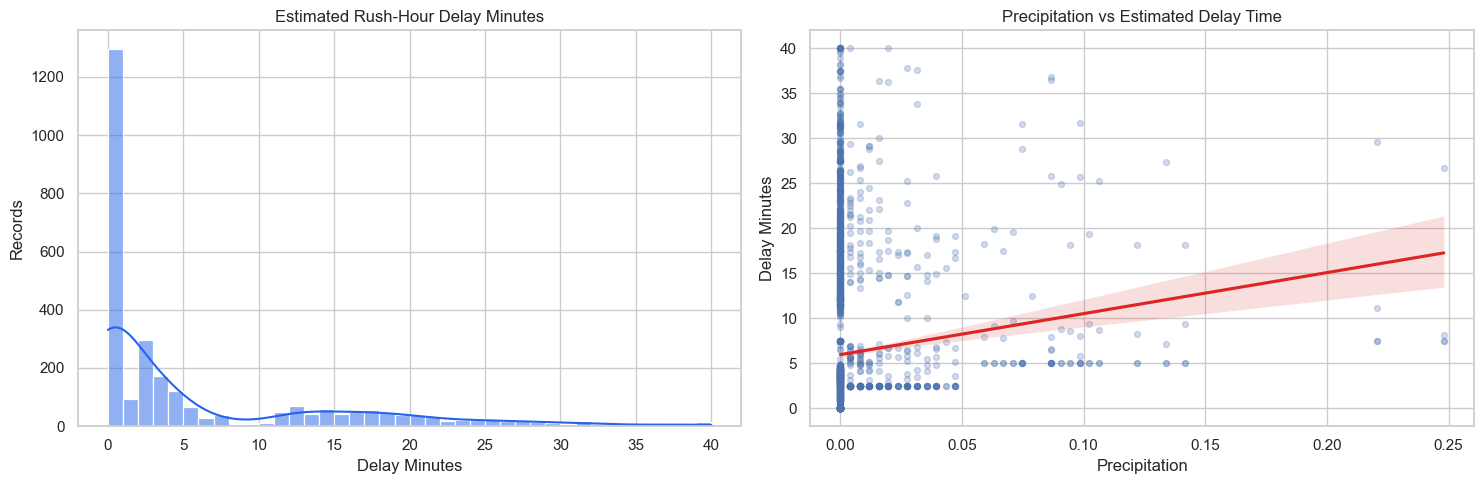

In [291]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(rush_df["delay_minutes"], bins=40, kde=True, ax=axes[0], color="#2563eb")
axes[0].set_title("Estimated Rush-Hour Delay Minutes")
axes[0].set_xlabel("Delay Minutes")
axes[0].set_ylabel("Records")

sns.regplot(
    data=rush_df,
    x="precipitation",
    y="delay_minutes",
    scatter_kws={"alpha": 0.25, "s": 18},
    line_kws={"color": "#dc2626"},
    ax=axes[1]
)
axes[1].set_title("Precipitation vs Estimated Delay Time")
axes[1].set_xlabel("Precipitation")
axes[1].set_ylabel("Delay Minutes")

plt.tight_layout()
plt.show()


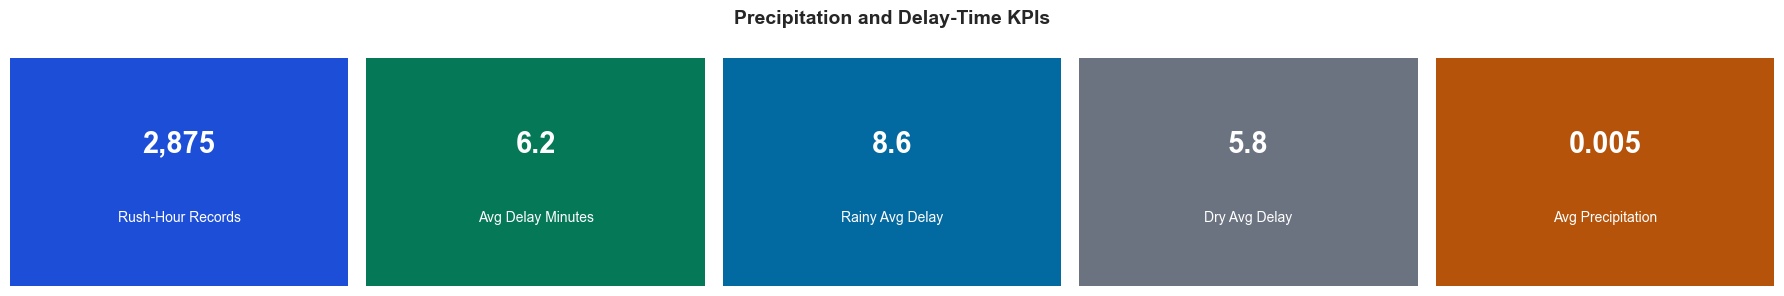

In [292]:
rainy_mask = rush_df["is_raining"].astype(str).str.lower().eq("true")
dry_mask = ~rainy_mask

kpi_values = {
    "Rush-Hour Records": f"{len(rush_df):,}",
    "Avg Delay Minutes": f"{rush_df['delay_minutes'].mean():.1f}",
    "Rainy Avg Delay": f"{rush_df.loc[rainy_mask, 'delay_minutes'].mean():.1f}" if rainy_mask.any() else "N/A",
    "Dry Avg Delay": f"{rush_df.loc[dry_mask, 'delay_minutes'].mean():.1f}" if dry_mask.any() else "N/A",
    "Avg Precipitation": f"{rush_df['precipitation'].mean():.3f}"
}

fig, axes = plt.subplots(1, len(kpi_values), figsize=(18, 3))
card_colors = ["#1d4ed8", "#047857", "#0369a1", "#6b7280", "#b45309"]

for ax, (label, value), color in zip(axes, kpi_values.items(), card_colors):
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=21, color="white", fontweight="bold")
    ax.text(0.5, 0.30, label, ha="center", va="center", fontsize=10, color="white")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle("Precipitation and Delay-Time KPIs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


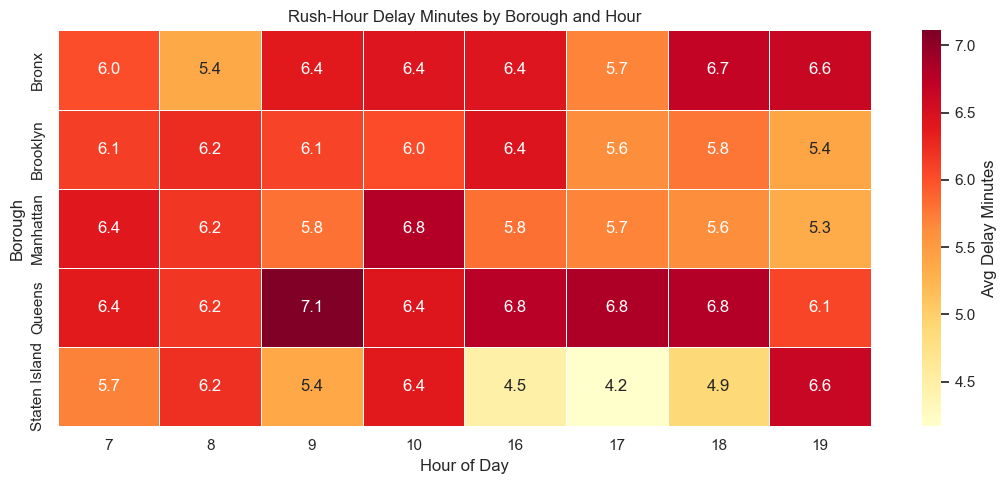

In [293]:
rush_heatmap = rush_df.pivot_table(
    index="boro",
    columns="hour",
    values="delay_minutes",
    aggfunc="mean"
)

plt.figure(figsize=(11, 5))
sns.heatmap(
    rush_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Avg Delay Minutes"}
)
plt.title("Rush-Hour Delay Minutes by Borough and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Borough")
plt.tight_layout()
plt.show()


In [294]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

baseline_features = ["vol", "hour", "boro", "street", "direction", "day_of_week"]
weather_features = baseline_features + ["temperature_2m", "precipitation", "is_raining", "rain_intensity"]
target = "delay_minutes"

categorical_cleanup_cols = ["boro", "street", "direction", "day_of_week", "is_raining", "rain_intensity"]
for col in categorical_cleanup_cols:
    rush_df[col] = rush_df[col].astype("object").where(rush_df[col].notna(), "missing").astype(str)

numeric_lookup = ["vol", "hour", "temperature_2m", "precipitation"]

target_diagnostics = pd.DataFrame({
    "metric": ["mean", "std", "min", "max"],
    "delay_minutes": [
        rush_df[target].mean(),
        rush_df[target].std(),
        rush_df[target].min(),
        rush_df[target].max()
    ]
})
print("Delay target diagnostics:")
display(target_diagnostics)
display(rush_df[["date", "hour", "boro", "street", "vol", target]].head(10))

correlation_rows = []
for col in numeric_lookup:
    correlation_rows.append({
        "feature": col,
        "correlation_with_delay_minutes": rush_df[[col, target]].corr().iloc[0, 1]
    })
feature_correlations = pd.DataFrame(correlation_rows).sort_values(
    "correlation_with_delay_minutes",
    key=lambda series: series.abs(),
    ascending=False
)
print("Numeric feature-target correlations:")
display(feature_correlations)

def build_regression_model(feature_cols):
    numeric_features = [col for col in feature_cols if col in numeric_lookup]
    categorical_features = [col for col in feature_cols if col not in numeric_features]

    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=42))
    ])

X_train, X_test, y_train, y_test = train_test_split(
    rush_df[weather_features],
    rush_df[target],
    test_size=0.25,
    random_state=42
)

baseline_model = build_regression_model(baseline_features)
weather_model = build_regression_model(weather_features)

baseline_model.fit(X_train[baseline_features], y_train)
weather_model.fit(X_train[weather_features], y_train)

def evaluate_predictions(name, features, ab_group, pred):
    return {
        "model": name,
        "features": features,
        "mae": mean_absolute_error(y_test, pred),
        "rmse": mean_squared_error(y_test, pred) ** 0.5,
        "r2": r2_score(y_test, pred),
        "ab_group": ab_group
    }

mean_prediction = pd.Series(y_train.mean(), index=y_test.index)
baseline_pred = pd.Series(
    baseline_model.predict(X_test[baseline_features]).clip(min=0),
    index=y_test.index
)
weather_pred = pd.Series(
    weather_model.predict(X_test[weather_features]).clip(min=0),
    index=y_test.index
)

model_results = pd.DataFrame([
    evaluate_predictions("mean_delay_benchmark", "train_mean_only", "Benchmark: mean", mean_prediction),
    evaluate_predictions("baseline_volume_time_location", "volume_time_location", "A: volume baseline", baseline_pred),
    evaluate_predictions("precipitation_aware", "volume_time_location_weather_precipitation", "B: precipitation-aware", weather_pred)
])

display(model_results)

pred_compare = X_test.copy()
pred_compare["actual_delay_minutes"] = y_test
pred_compare["mean_prediction"] = mean_prediction
pred_compare["baseline_prediction"] = baseline_pred
pred_compare["precipitation_prediction"] = weather_pred
display(pred_compare[["vol", "hour", "boro", "precipitation", "rain_intensity", "actual_delay_minutes", "mean_prediction", "baseline_prediction", "precipitation_prediction"]].head())


Delay target diagnostics:


,metric,delay_minutes
0,mean,6.182362
1,std,8.980598
2,min,0.000000
3,max,40.000000


,date,hour,boro,street,vol,delay_minutes
41,2023-11-16,7,Brooklyn,AVENUE J,28,0.00
42,2023-11-16,7,Brooklyn,AVENUE J,43,3.64
43,2023-11-16,7,Brooklyn,AVENUE J,31,0.00
44,2023-11-16,7,Brooklyn,AVENUE J,58,20.23
45,2023-11-16,8,Brooklyn,AVENUE J,41,12.24
46,2023-11-16,8,Brooklyn,AVENUE J,39,2.63
47,2023-11-16,8,Brooklyn,AVENUE J,34,0.00
48,2023-11-16,8,Brooklyn,AVENUE J,18,0.00
49,2023-11-16,9,Brooklyn,AVENUE J,23,0.00
50,2023-11-16,9,Brooklyn,AVENUE J,28,3.08


Numeric feature-target correlations:


,feature,correlation_with_delay_minutes
3,precipitation,0.102364
0,vol,0.027560
2,temperature_2m,-0.012410
1,hour,-0.007054


,model,features,mae,rmse,r2,ab_group
0,mean_delay_benchmark,train_mean_only,7.187854,9.142750,-0.001383,Benchmark: mean
1,baseline_volume_time_location,volume_time_location,6.727008,8.960907,0.038055,A: volume baseline
2,precipitation_aware,volume_time_location_weather_precipitation,6.954849,9.154034,-0.003856,B: precipitation-aware


,vol,hour,boro,precipitation,rain_intensity,actual_delay_minutes,mean_prediction,baseline_prediction,precipitation_prediction
2239,128,17,Brooklyn,0.0,none,40.00,6.097393,12.752588,10.460969
7449,879,19,Brooklyn,0.0,none,15.39,6.097393,2.106766,2.377582
3889,94,16,Brooklyn,0.0,none,7.50,6.097393,7.332724,3.682242
5316,151,9,Manhattan,0.0,none,0.00,6.097393,5.594001,5.487132
2796,107,8,Queens,0.0,none,0.00,6.097393,8.959181,11.132140


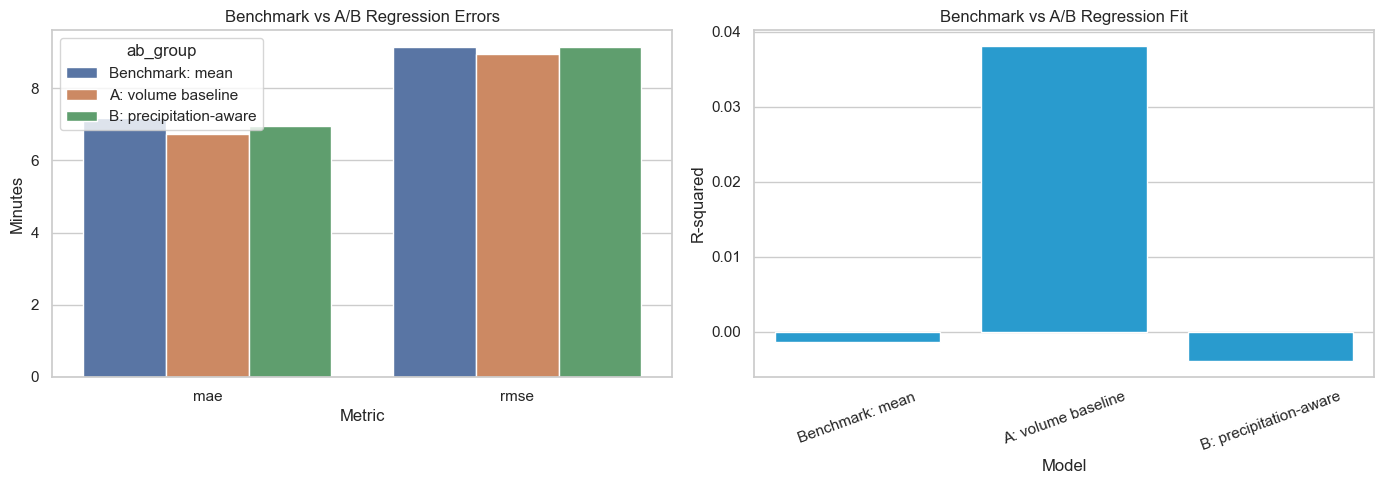

,precipitation_model_minus_volume_baseline
mae,0.227841
rmse,0.193127
r2,-0.041911


In [295]:
model_results_long = model_results.melt(
    id_vars=["model", "features", "ab_group"],
    value_vars=["mae", "rmse", "r2"],
    var_name="metric",
    value_name="score"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
error_metrics = model_results_long[model_results_long["metric"].isin(["mae", "rmse"])]
sns.barplot(data=error_metrics, x="metric", y="score", hue="ab_group", ax=axes[0])
axes[0].set_title("Benchmark vs A/B Regression Errors")
axes[0].set_xlabel("Metric")
axes[0].set_ylabel("Minutes")

sns.barplot(data=model_results, x="ab_group", y="r2", ax=axes[1], color="#0ea5e9")
axes[1].set_title("Benchmark vs A/B Regression Fit")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("R-squared")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

ab_lift = model_results.set_index("model").loc["precipitation_aware", ["mae", "rmse", "r2"]] - model_results.set_index("model").loc["baseline_volume_time_location", ["mae", "rmse", "r2"]]
display(ab_lift.to_frame("precipitation_model_minus_volume_baseline"))


In [296]:
feature_names = weather_model.named_steps["preprocessor"].get_feature_names_out()
importances = weather_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

importance_df["clean_feature"] = (
    importance_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

precip_importance = importance_df[importance_df["clean_feature"].str.contains("precipitation|is_raining|rain_intensity", regex=True)]
print(f"Combined precipitation feature importance: {precip_importance['importance'].sum():.3f}")
display(importance_df.head(20))
display(precip_importance)


Combined precipitation feature importance: 0.040


,feature,importance,clean_feature
0,num__vol,0.429259,vol
2,num__temperature_2m,0.165884,temperature_2m
1,num__hour,0.089661,hour
3,num__precipitation,0.029803,precipitation
11,cat__street_218 PLACE,0.015708,street_218 PLACE
16,cat__street_46 AVENUE,0.013186,street_46 AVENUE
85,cat__day_of_week_Tuesday,0.012260,day_of_week_Tuesday
7,cat__boro_Queens,0.012176,boro_Queens
79,cat__direction_WB,0.011208,direction_WB
76,cat__direction_EB,0.010296,direction_EB


,feature,importance,clean_feature
3,num__precipitation,0.029803,precipitation
92,cat__rain_intensity_none,0.003172,rain_intensity_none
87,cat__is_raining_False,0.002470,is_raining_False
88,cat__is_raining_True,0.002248,is_raining_True
90,cat__rain_intensity_light,0.001608,rain_intensity_light
91,cat__rain_intensity_moderate,0.000825,rain_intensity_moderate
89,cat__rain_intensity_heavy,0.000007,rain_intensity_heavy


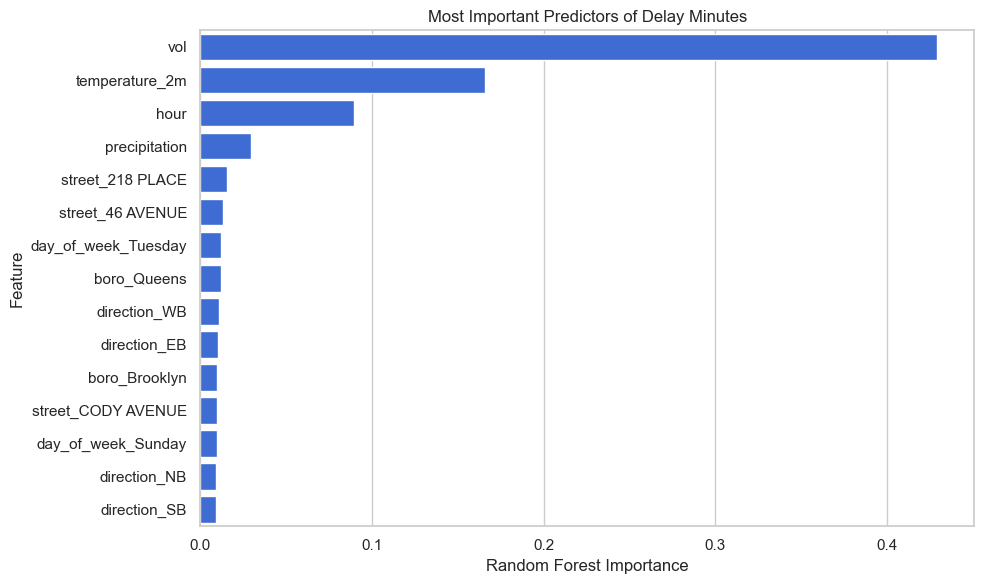

In [297]:
top_importance = importance_df.head(15).copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_importance, x="importance", y="clean_feature", color="#2563eb")
plt.title("Most Important Predictors of Delay Minutes")
plt.xlabel("Random Forest Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [298]:
rain_effect = rush_df.groupby("rain_intensity", observed=True).agg(
    records=("delay_minutes", "size"),
    avg_delay_minutes=("delay_minutes", "mean"),
    median_delay_minutes=("delay_minutes", "median"),
    avg_delay_index=("delay_index", "mean"),
    avg_volume=("vol", "mean"),
    avg_precipitation=("precipitation", "mean")
).reset_index()

boro_rain_effect = rush_df.groupby(["boro", "rain_intensity"], observed=True).agg(
    records=("delay_minutes", "size"),
    avg_delay_minutes=("delay_minutes", "mean"),
    avg_delay_index=("delay_index", "mean"),
    avg_volume=("vol", "mean"),
    avg_precipitation=("precipitation", "mean")
).reset_index().sort_values("avg_delay_minutes", ascending=False)

display(rain_effect)
display(boro_rain_effect.head(20))


,rain_intensity,records,avg_delay_minutes,median_delay_minutes,avg_delay_index,avg_volume,avg_precipitation
0,heavy,8,13.200000,7.845,1.018194,108.875000,0.234252
1,light,347,8.023141,2.500,1.016269,128.925072,0.016497
2,moderate,73,10.723973,5.000,0.996455,90.424658,0.091576
3,none,2447,5.762897,0.000,1.011805,153.101757,0.000000


,boro,rain_intensity,records,avg_delay_minutes,avg_delay_index,avg_volume,avg_precipitation
0,Bronx,heavy,8,13.200000,1.018194,108.875000,0.234252
5,Brooklyn,moderate,5,12.000000,1.002676,347.400000,0.094488
8,Manhattan,moderate,7,11.138571,1.003311,219.857143,0.068054
11,Queens,moderate,53,10.608491,0.992208,56.735849,0.092483
2,Bronx,moderate,8,10.328750,1.014706,39.750000,0.104331
10,Queens,light,108,8.592500,1.058020,64.833333,0.018956
7,Manhattan,light,45,7.825111,1.003195,146.600000,0.006737
4,Brooklyn,light,114,7.759298,0.995810,183.245614,0.013710
1,Bronx,light,80,7.741875,0.996411,128.100000,0.022638
12,Queens,none,677,5.929483,1.022505,141.920236,0.000000


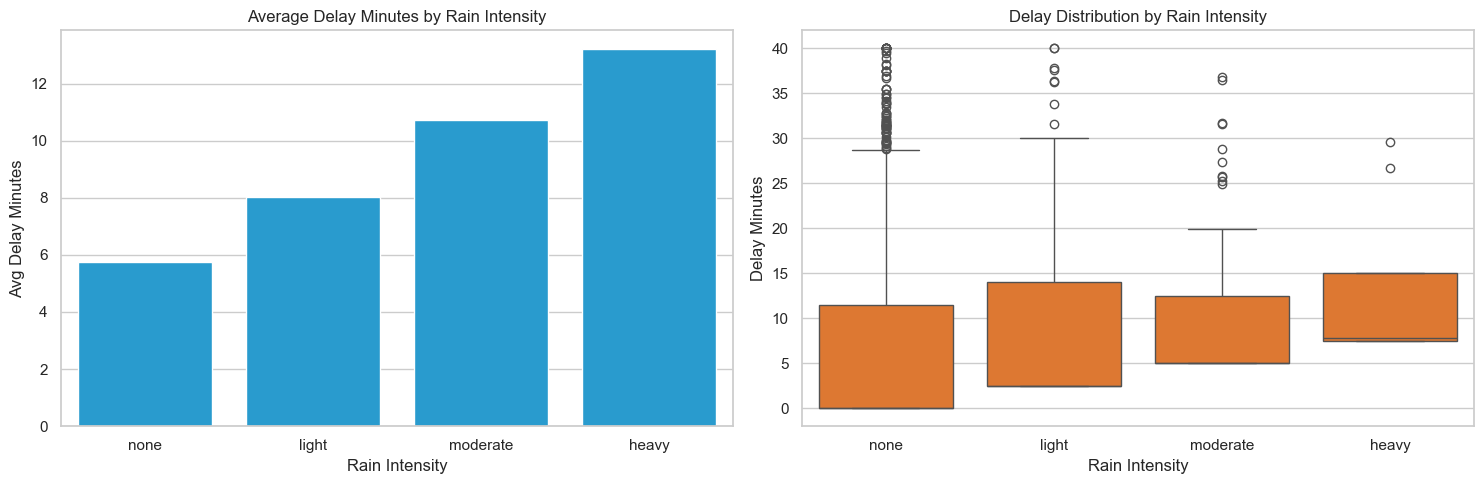

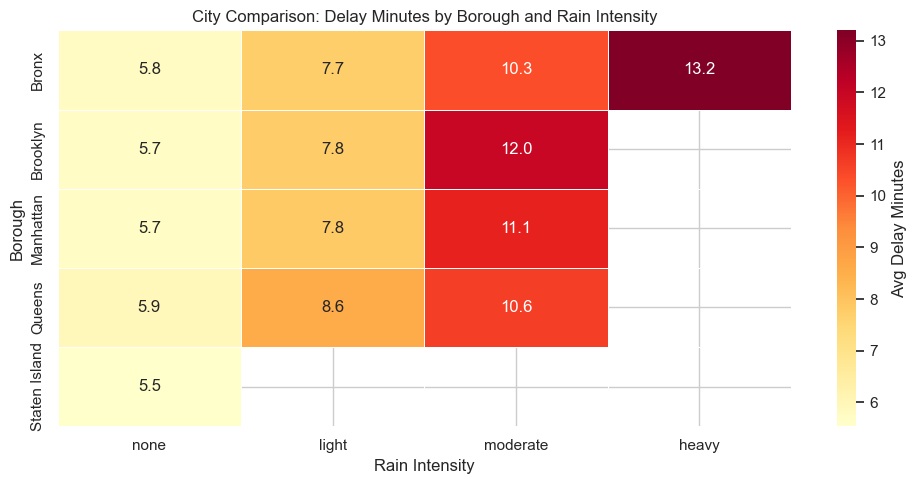

In [299]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

rain_order = ["none", "light", "moderate", "heavy"]
sns.barplot(data=rain_effect, x="rain_intensity", y="avg_delay_minutes", order=rain_order, ax=axes[0], color="#0ea5e9")
axes[0].set_title("Average Delay Minutes by Rain Intensity")
axes[0].set_xlabel("Rain Intensity")
axes[0].set_ylabel("Avg Delay Minutes")

sns.boxplot(data=rush_df, x="rain_intensity", y="delay_minutes", order=rain_order, ax=axes[1], color="#f97316")
axes[1].set_title("Delay Distribution by Rain Intensity")
axes[1].set_xlabel("Rain Intensity")
axes[1].set_ylabel("Delay Minutes")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(
    boro_rain_effect.pivot(index="boro", columns="rain_intensity", values="avg_delay_minutes").reindex(columns=rain_order),
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Avg Delay Minutes"}
)
plt.title("City Comparison: Delay Minutes by Borough and Rain Intensity")
plt.xlabel("Rain Intensity")
plt.ylabel("Borough")
plt.tight_layout()
plt.show()


In [300]:
rush_scored = rush_df.copy()
rush_scored["predicted_delay_minutes"] = weather_model.predict(rush_scored[weather_features]).clip(min=0)
rush_scored["prediction_error_minutes"] = rush_scored["delay_minutes"] - rush_scored["predicted_delay_minutes"]
rush_scored["delay_level"] = pd.cut(
    rush_scored["predicted_delay_minutes"],
    bins=[-0.001, 5, 15, 30, float("inf")],
    labels=["Low", "Moderate", "High", "Severe"]
)

precip_thresholds = sorted(rush_scored["precipitation"].dropna().unique())
precip_thresholds = [x for x in precip_thresholds if x > 0]

threshold_rows = []
for threshold in precip_thresholds:
    lower = rush_scored[rush_scored["precipitation"] < threshold]
    upper = rush_scored[rush_scored["precipitation"] >= threshold]
    if len(lower) >= 100 and len(upper) >= 100:
        threshold_rows.append({
            "precipitation_threshold": threshold,
            "below_avg_predicted_delay_minutes": lower["predicted_delay_minutes"].mean(),
            "above_avg_predicted_delay_minutes": upper["predicted_delay_minutes"].mean(),
            "delay_minute_jump": upper["predicted_delay_minutes"].mean() - lower["predicted_delay_minutes"].mean(),
            "below_records": len(lower),
            "above_records": len(upper)
        })

precip_tipping = pd.DataFrame(
    threshold_rows,
    columns=[
        "precipitation_threshold",
        "below_avg_predicted_delay_minutes",
        "above_avg_predicted_delay_minutes",
        "delay_minute_jump",
        "below_records",
        "above_records",
    ]
).sort_values("delay_minute_jump", ascending=False)
display(precip_tipping.head(10))

display(rush_scored[["date", "hour", "boro", "street", "precipitation", "rain_intensity", "delay_minutes", "predicted_delay_minutes", "delay_level"]].head())


,precipitation_threshold,below_avg_predicted_delay_minutes,above_avg_predicted_delay_minutes,delay_minute_jump,below_records,above_records
9,0.039370,5.963485,9.905924,3.942439,2762,113
8,0.035433,5.963020,9.509301,3.546281,2749,126
7,0.031496,5.944452,9.467106,3.522655,2733,142
6,0.027559,5.924500,9.185194,3.260694,2704,171
5,0.023622,5.914553,9.117695,3.203141,2692,183
3,0.015748,5.848885,9.051241,3.202356,2633,242
4,0.019685,5.888701,9.079522,3.190821,2668,207
2,0.011811,5.815680,8.969429,3.153749,2599,276
1,0.007874,5.778902,8.583993,2.805091,2527,348
0,0.003937,5.725263,8.366346,2.641083,2447,428


,date,hour,boro,street,precipitation,rain_intensity,delay_minutes,predicted_delay_minutes,delay_level
41,2023-11-16,7,Brooklyn,AVENUE J,0.0,none,0.00,3.565346,Low
42,2023-11-16,7,Brooklyn,AVENUE J,0.0,none,3.64,5.769702,Moderate
43,2023-11-16,7,Brooklyn,AVENUE J,0.0,none,0.00,3.357598,Low
44,2023-11-16,7,Brooklyn,AVENUE J,0.0,none,20.23,10.728152,Moderate
45,2023-11-16,8,Brooklyn,AVENUE J,0.0,none,12.24,6.199227,Moderate


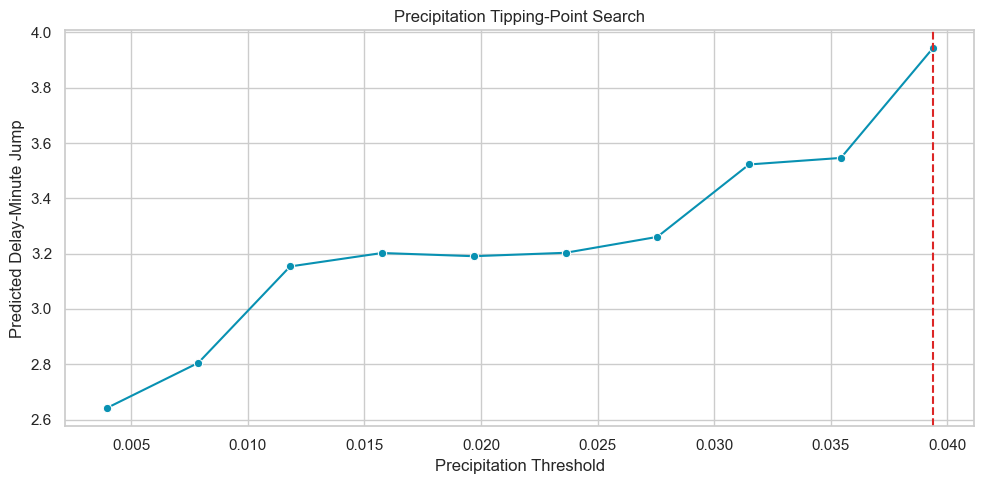

In [301]:
plt.figure(figsize=(10, 5))

if len(precip_tipping):
    precip_plot = precip_tipping.sort_values("precipitation_threshold")
    sns.lineplot(data=precip_plot, x="precipitation_threshold", y="delay_minute_jump", marker="o", color="#0891b2")
    best_precip = precip_tipping.iloc[0]
    plt.axvline(best_precip["precipitation_threshold"], color="#dc2626", linestyle="--")
    plt.title("Precipitation Tipping-Point Search")
    plt.xlabel("Precipitation Threshold")
    plt.ylabel("Predicted Delay-Minute Jump")
else:
    plt.text(0.5, 0.5, "No reliable precipitation tipping point", ha="center", va="center")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [302]:
benchmark_metrics = model_results.set_index("model").loc["mean_delay_benchmark"]
baseline_metrics = model_results.set_index("model").loc["baseline_volume_time_location"]
precip_metrics = model_results.set_index("model").loc["precipitation_aware"]

baseline_rmse_vs_mean = baseline_metrics["rmse"] - benchmark_metrics["rmse"]
precip_rmse_vs_baseline = precip_metrics["rmse"] - baseline_metrics["rmse"]
precip_mae_vs_baseline = precip_metrics["mae"] - baseline_metrics["mae"]
precip_r2_vs_baseline = precip_metrics["r2"] - baseline_metrics["r2"]
best_precip_threshold = precip_tipping.iloc[0] if len(precip_tipping) else None

print("Q1: What is the relationship between precipitation and estimated delay time?")
display(rain_effect)

print("Q2: Does traffic volume fix the weak-delay prediction problem?")
print(f"Volume baseline RMSE change vs mean benchmark: {baseline_rmse_vs_mean:.3f} minutes (negative is better)")
print(f"Volume baseline R-squared: {baseline_metrics['r2']:.3f}")

print("Q3: Does precipitation improve delay-time regression after volume/time/location are included?")
print(f"Precipitation model RMSE change vs volume baseline: {precip_rmse_vs_baseline:.3f} minutes (negative is better)")
print(f"Precipitation model MAE change vs volume baseline: {precip_mae_vs_baseline:.3f} minutes (negative is better)")
print(f"Precipitation model R-squared change vs volume baseline: {precip_r2_vs_baseline:.3f} (positive is better)")

print("Q4: Which weather condition creates the sharpest delay increase?")
if best_precip_threshold is not None:
    print(f"Strongest precipitation tipping candidate: >= {best_precip_threshold['precipitation_threshold']:.3f}, predicted delay jump {best_precip_threshold['delay_minute_jump']:.2f} minutes")
else:
    print("No reliable precipitation tipping point found with enough records on both sides.")

print("Dashboard mapping:")
print("1. Live predictions: rush_scored and tableau_live_predictions")
print("2. City comparison: boro_rain_effect and tableau_city_comparison")
print("3. A/B results: model_results and tableau_ab_results")


Q1: What is the relationship between precipitation and estimated delay time?


,rain_intensity,records,avg_delay_minutes,median_delay_minutes,avg_delay_index,avg_volume,avg_precipitation
0,heavy,8,13.200000,7.845,1.018194,108.875000,0.234252
1,light,347,8.023141,2.500,1.016269,128.925072,0.016497
2,moderate,73,10.723973,5.000,0.996455,90.424658,0.091576
3,none,2447,5.762897,0.000,1.011805,153.101757,0.000000


Q2: Does traffic volume fix the weak-delay prediction problem?
Volume baseline RMSE change vs mean benchmark: -0.182 minutes (negative is better)
Volume baseline R-squared: 0.038
Q3: Does precipitation improve delay-time regression after volume/time/location are included?
Precipitation model RMSE change vs volume baseline: 0.193 minutes (negative is better)
Precipitation model MAE change vs volume baseline: 0.228 minutes (negative is better)
Precipitation model R-squared change vs volume baseline: -0.042 (positive is better)
Q4: Which weather condition creates the sharpest delay increase?
Strongest precipitation tipping candidate: >= 0.039, predicted delay jump 3.94 minutes
Dashboard mapping:
1. Live predictions: rush_scored and tableau_live_predictions
2. City comparison: boro_rain_effect and tableau_city_comparison
3. A/B results: model_results and tableau_ab_results


### Suggested Interpretation

Use `rain_effect` to describe how average delay minutes change from dry to rainy conditions. The `delay_minutes` target is a congestion proxy built from local traffic baselines, volume percentile spikes, IQR-normalized abnormal volume, and precipitation pressure. The model now includes `vol` because actual traffic volume is the core congestion signal. Interpret Model B as a precipitation-aware congestion scoring model, not as proof that weather alone causes delay. Use `model_results` to compare the mean benchmark, Model A (volume/time/location baseline), and Model B (volume/time/location plus weather). Use `boro_rain_effect`, `rush_scored`, and the Tableau export tables to build the required live predictions, city comparison, and A/B results dashboards.


## 8. Tableau Dashboard Tables

Create MySQL tables designed for the three required Tableau dashboards: **live predictions**, **city comparison**, and **A/B results**.


In [303]:
import importlib
import tableau_exports

importlib.reload(tableau_exports)
from tableau_exports import build_tableau_tables, write_tableau_tables

tableau_tables = build_tableau_tables(
    rush_df=rush_df,
    rush_scored=rush_scored,
    model_results=model_results,
    weather_features=weather_features,
    weather_model=weather_model
)

for table_name, table_df in tableau_tables.items():
    print(f"{table_name}: {table_df.shape[0]:,} rows x {table_df.shape[1]:,} columns")

display(tableau_tables["tableau_live_predictions"].head())
display(tableau_tables["tableau_city_comparison"].head())
display(tableau_tables["tableau_ab_results"])

if "engine" in globals():
    written_tables = write_tableau_tables(engine, tableau_tables)
    print("Written to MySQL:")
    for table_name in written_tables:
        print(f"- {table_name}")
else:
    print("MySQL engine is not defined. Run the database connection cell before writing Tableau tables.")


tableau_live_predictions: 2,875 rows x 29 columns
tableau_live_predictions_by_borough: 5 rows x 9 columns
tableau_city_comparison: 14 rows x 11 columns
tableau_ab_results: 3 rows x 9 columns
tableau_today_weather_predictions: 5 rows x 14 columns


,date,hour,boro,street,fromst,tost,direction,vol,expected_volume,p75_volume,...,delay_minutes,predicted_delay_minutes,delay_level,rain_intensity,temperature_2m,precipitation,is_raining,day_of_week,prediction_error_minutes,is_raining_flag
41,2023-11-16,7,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,28,37.0,46.75,...,0.00,3.565346,Low,none,36.410000,0.0,False,Thursday,-3.565346,False
42,2023-11-16,7,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,43,37.0,46.75,...,3.64,5.769702,Moderate,none,36.410000,0.0,False,Thursday,-2.129702,False
43,2023-11-16,7,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,31,37.0,46.75,...,0.00,3.357598,Low,none,36.410000,0.0,False,Thursday,-3.357598,False
44,2023-11-16,7,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,58,37.0,46.75,...,20.23,10.728152,Moderate,none,36.410000,0.0,False,Thursday,9.501848,False
45,2023-11-16,8,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,41,36.5,39.50,...,12.24,6.199227,Moderate,none,36.049999,0.0,False,Thursday,6.040773,False


,boro,rain_intensity,records,avg_delay_minutes,avg_predicted_delay_minutes,avg_delay_index,avg_temperature,avg_precipitation,latitude,longitude,delay_level
0,Bronx,heavy,8,13.200000,11.433809,1.018194,57.919998,0.234252,40.8448,-73.8648,Moderate
1,Bronx,light,80,7.741875,7.523912,0.996411,52.358002,0.022638,40.8448,-73.8648,Moderate
2,Bronx,moderate,8,10.328750,10.449934,1.014706,54.410004,0.104331,40.8448,-73.8648,Moderate
3,Bronx,none,469,5.753134,5.607222,1.014029,57.421257,0.000000,40.8448,-73.8648,Moderate
4,Brooklyn,light,114,7.759298,7.665411,0.995810,55.211315,0.013710,40.6782,-73.9442,Moderate


,model,features,mae,rmse,r2,ab_group,dashboard,recommendation_score,recommendation
0,mean_delay_benchmark,train_mean_only,7.187854,9.142750,-0.001383,Benchmark: mean,A/B results,-9.142750,Compare
1,baseline_volume_time_location,volume_time_location,6.727008,8.960907,0.038055,A: volume baseline,A/B results,-8.960907,Recommended
2,precipitation_aware,volume_time_location_weather_precipitation,6.954849,9.154034,-0.003856,B: precipitation-aware,A/B results,-9.154034,Compare


Written to MySQL:
- tableau_live_predictions
- tableau_live_predictions_by_borough
- tableau_city_comparison
- tableau_ab_results
- tableau_today_weather_predictions
